# Titanic Passenger Survival Analysis

## **Objective:** Apply supervised machine learning to predict whether a Titanic passenger survived,
uncover the key drivers of survival, and evaluate multiple classification models.

---


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay,
)
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13, "axes.labelsize": 11})

## 2. Data Loading

In [2]:
df = pd.read_csv(Path("titanic_passengers.csv"))
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Shape: 891 rows × 12 columns


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


## 3. Exploratory Data Analysis

### 3.1 Missing Values


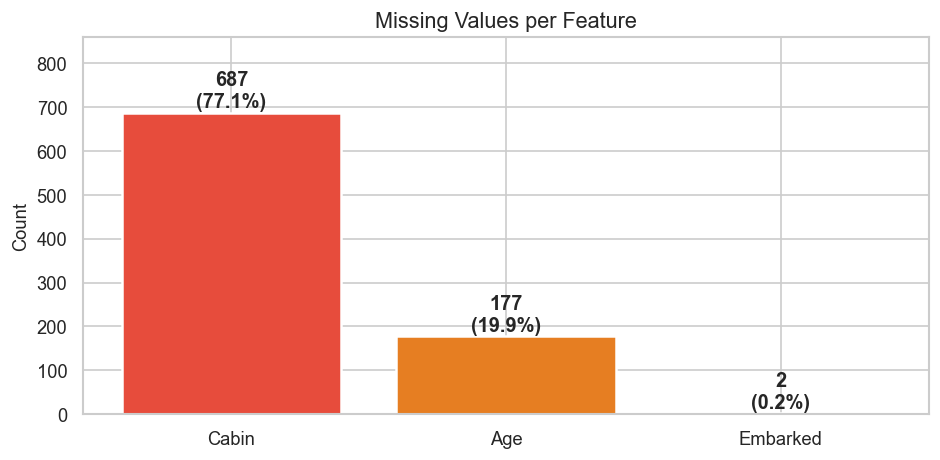

          Missing  Percent
Cabin         687     77.1
Age           177     19.9
Embarked        2      0.2


In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
pct = (missing / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(missing.index, missing.values, color=["#e74c3c", "#e67e22", "#3498db"],
              edgecolor="white", linewidth=1.5)
for bar, val, p in zip(bars, missing.values, pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
            f"{val}\n({p}%)", ha="center", va="bottom", fontweight="bold")
ax.set(title="Missing Values per Feature", ylabel="Count", ylim=(0, missing.max() * 1.25))
plt.tight_layout()
plt.show()

print(missing.to_frame("Missing").assign(Percent=pct))

### 3.2 Survival Overview

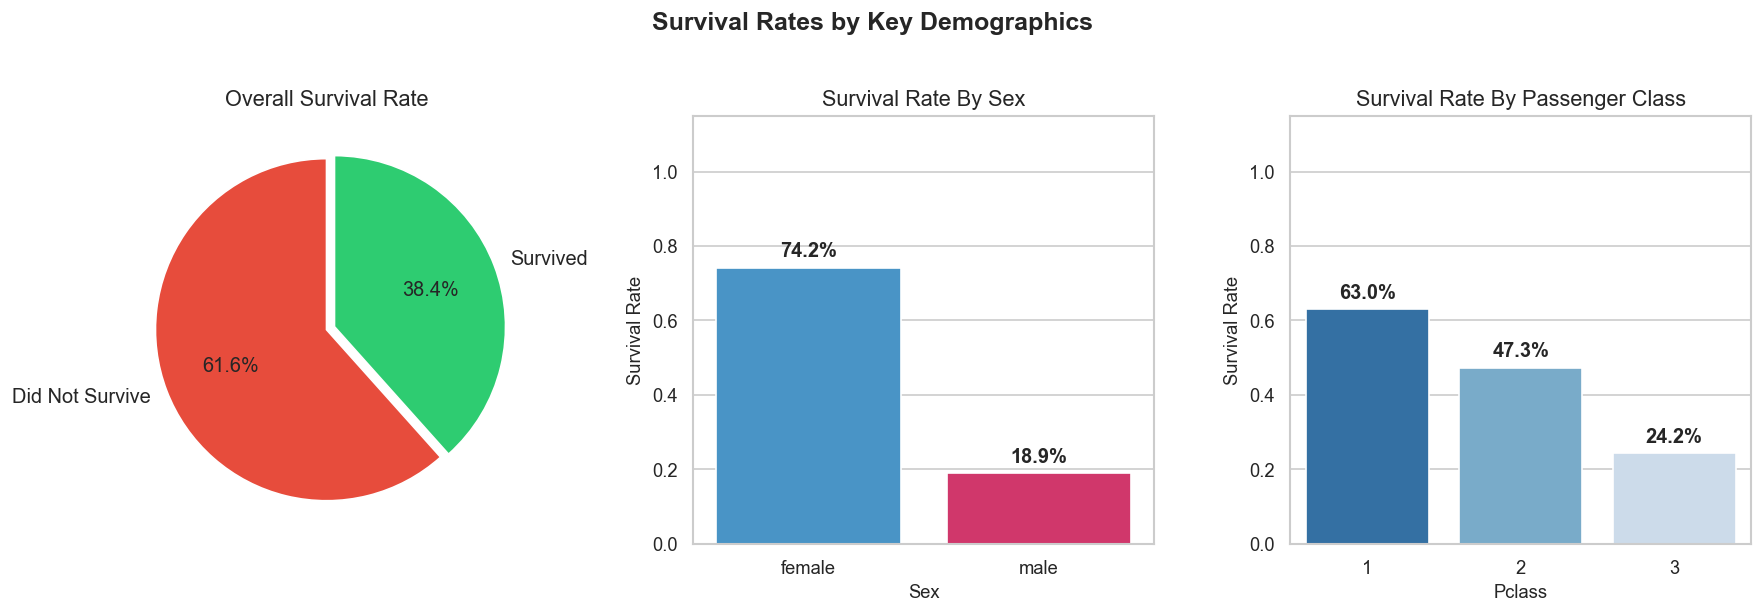

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Pie chart — overall rate
counts = df["Survived"].value_counts()
axes[0].pie(counts, labels=["Did Not Survive", "Survived"],
            autopct="%1.1f%%", startangle=90,
            colors=["#e74c3c", "#2ecc71"], explode=(0, 0.05),
            textprops={"fontsize": 12})
axes[0].set_title("Overall Survival Rate")

# Bar — by Sex
for ax, col, palette, title in [
    (axes[1], "Sex",    ["#3498db", "#e91e63"], "By Sex"),
    (axes[2], "Pclass", "Blues_r",              "By Passenger Class"),
]:
    rates = df.groupby(col)["Survived"].mean().reset_index()
    sns.barplot(data=rates, x=col, y="Survived", ax=ax, palette=palette)
    ax.set(title=f"Survival Rate {title}", ylabel="Survival Rate", ylim=(0, 1.15))
    for bar, val in zip(ax.patches, rates["Survived"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03,
                f"{val:.1%}", ha="center", fontweight="bold", fontsize=12)

plt.suptitle("Survival Rates by Key Demographics", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 3.3 Age & Fare Distributions

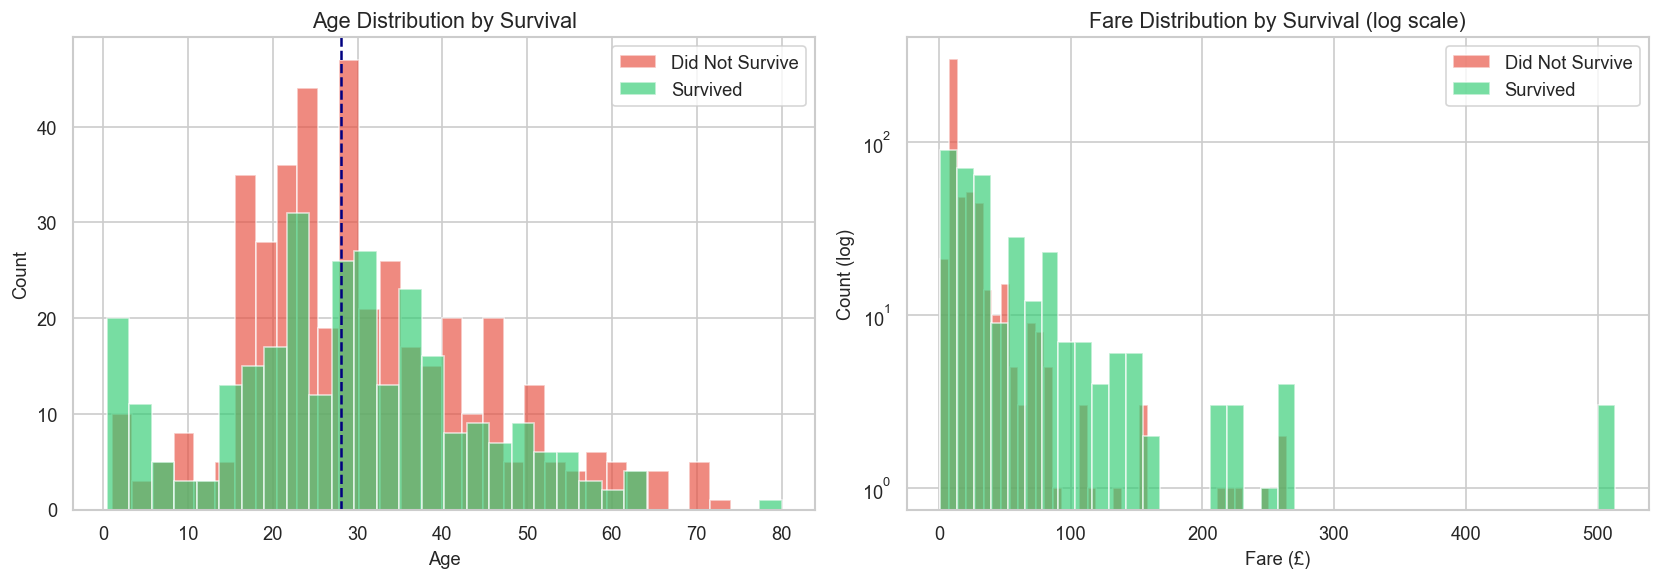

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age by survival
for survived, label, color in [(0, "Did Not Survive", "#e74c3c"), (1, "Survived", "#2ecc71")]:
    axes[0].hist(df[df["Survived"] == survived]["Age"].dropna(),
                 bins=30, alpha=0.65, label=label, color=color, edgecolor="white")
axes[0].set(title="Age Distribution by Survival", xlabel="Age", ylabel="Count")
axes[0].legend()
axes[0].axvline(df["Age"].median(), color="navy", linestyle="--", label=f"Median Age ({df['Age'].median():.0f})")

# Fare by survival (log scale)
for survived, label, color in [(0, "Did Not Survive", "#e74c3c"), (1, "Survived", "#2ecc71")]:
    axes[1].hist(df[df["Survived"] == survived]["Fare"] + 1,
                 bins=40, alpha=0.65, label=label, color=color, edgecolor="white", log=True)
axes[1].set(title="Fare Distribution by Survival (log scale)",
            xlabel="Fare (£)", ylabel="Count (log)")
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.4 Interaction Effects

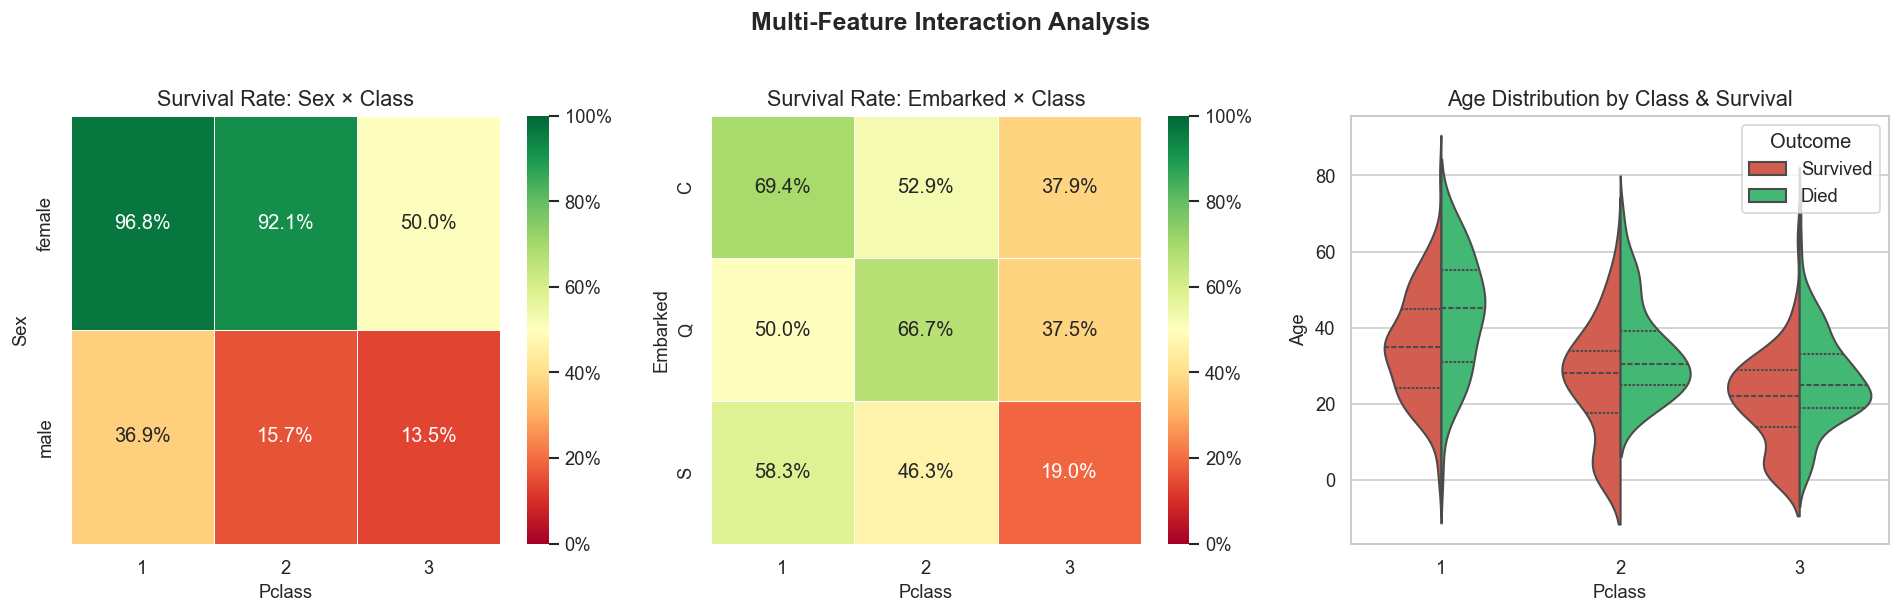

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Sex × Class heatmap
pivot = df.pivot_table(values="Survived", index="Sex", columns="Pclass", aggfunc="mean")
sns.heatmap(pivot, annot=True, fmt=".1%", cmap="RdYlGn", ax=axes[0],
            linewidths=0.5, vmin=0, vmax=1, cbar_kws={"format": "{x:.0%}"})
axes[0].set_title("Survival Rate: Sex × Class")

# Embarked × Class
pivot2 = df.pivot_table(values="Survived", index="Embarked", columns="Pclass", aggfunc="mean")
sns.heatmap(pivot2, annot=True, fmt=".1%", cmap="RdYlGn", ax=axes[1],
            linewidths=0.5, vmin=0, vmax=1, cbar_kws={"format": "{x:.0%}"})
axes[1].set_title("Survival Rate: Embarked × Class")

# Age violin by class and survival
df_plot = df.copy()
df_plot["Survived_Label"] = df_plot["Survived"].map({0: "Died", 1: "Survived"})
sns.violinplot(data=df_plot, x="Pclass", y="Age", hue="Survived_Label",
               split=True, ax=axes[2], palette=["#e74c3c", "#2ecc71"],
               inner="quartile")
axes[2].set_title("Age Distribution by Class & Survival")
axes[2].legend(title="Outcome")

plt.suptitle("Multi-Feature Interaction Analysis", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 3.5 Family Size & Embarkation

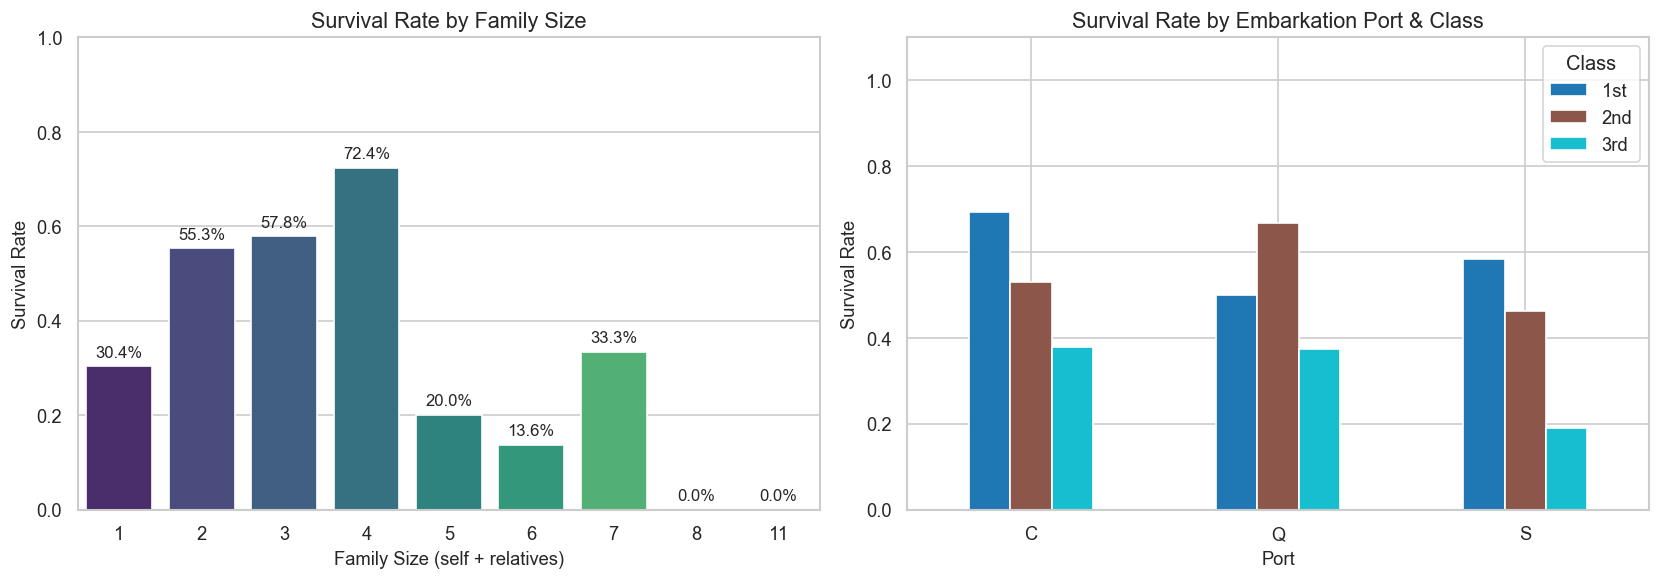

In [9]:
df["FamilySizeEDA"] = df["SibSp"] + df["Parch"] + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Family size survival rate
fam_rates = df.groupby("FamilySizeEDA")["Survived"].mean().reset_index()
sns.barplot(data=fam_rates, x="FamilySizeEDA", y="Survived", ax=axes[0], palette="viridis")
axes[0].set(title="Survival Rate by Family Size", xlabel="Family Size (self + relatives)",
            ylabel="Survival Rate", ylim=(0, 1))
for bar, val in zip(axes[0].patches, fam_rates["Survived"]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                 f"{val:.1%}", ha="center", fontsize=10)

# Embarkation survival rate with class breakdown
embark_class = (df.groupby(["Embarked", "Pclass"])["Survived"]
                  .mean().unstack().round(3))
embark_class.plot(kind="bar", ax=axes[1], colormap="tab10", edgecolor="white")
axes[1].set(title="Survival Rate by Embarkation Port & Class",
            xlabel="Port", ylabel="Survival Rate", ylim=(0, 1.1))
axes[1].legend(title="Class", labels=["1st", "2nd", "3rd"])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

## 4. Data Cleaning & Feature Engineering

**Strategy:**
- **Age** (177 missing, 20%): impute with median grouped by passenger title — more accurate than a global median because "Master" passengers are children and "Mrs" are older adults.
- **Embarked** (2 missing): fill with mode ("S").
- **Cabin** (687 missing, 77%): too sparse to impute; convert to binary `HasCabin` indicator.
- **Name / Ticket / PassengerId**: dropped after extracting useful information.


In [10]:
TITLE_MAP = {
    "Mr": "Mr", "Miss": "Miss", "Mrs": "Mrs", "Master": "Master",
    "Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs",
    "Lady": "Rare", "Sir": "Rare", "Don": "Rare", "Jonkheer": "Rare",
    "Dr": "Rare", "Rev": "Rare", "Major": "Rare", "Col": "Rare", "Capt": "Rare",
}

def engineer_features(raw: pd.DataFrame) -> pd.DataFrame:
    df = raw.copy()

    # Title — extracted, normalised, used for Age imputation
    df["Title"] = df["Name"].str.extract(r", ([A-Za-z]+)\.").squeeze().map(TITLE_MAP).fillna("Rare")
    age_medians = df.groupby("Title")["Age"].median()
    df["Age"] = df.apply(
        lambda r: age_medians[r["Title"]] if pd.isna(r["Age"]) else r["Age"], axis=1
    )

    # Embarked — fill 2 missing with mode
    df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

    # Family features
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
    df["IsAlone"]    = (df["FamilySize"] == 1).astype(int)

    # Cabin presence (binary signal — higher-class passengers have cabin records)
    df["HasCabin"] = df["Cabin"].notna().astype(int)

    # Binned continuous features
    df["FareBin"] = pd.qcut(df["Fare"], q=4, labels=["Low", "Mid", "High", "Premium"])
    df["AgeBin"]  = pd.cut(df["Age"], bins=[0, 12, 18, 35, 60, 100],
                           labels=["Child", "Teen", "YoungAdult", "Adult", "Senior"])

    return df.drop(columns=["Name", "Ticket", "Cabin", "PassengerId"])

df_clean = engineer_features(df)
print(f"Engineered shape: {df_clean.shape}")
df_clean.head(3)

Engineered shape: (891, 15)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySizeEDA,Title,FamilySize,IsAlone,HasCabin,FareBin,AgeBin
0,0,3,male,22.0,1,0,7.2500,S,2,Mr,2,0,0,Low,YoungAdult
1,1,1,female,38.0,1,0,71.2833,C,2,Mrs,2,0,1,Premium,Adult
2,1,3,female,26.0,0,0,7.9250,S,1,Miss,1,1,0,Mid,YoungAdult


In [11]:
# Survival rate by extracted Title — validates imputation logic
title_stats = (df_clean.groupby("Title")["Survived"]
               .agg(["mean", "count"])
               .rename(columns={"mean": "SurvivalRate", "count": "Count"})
               .sort_values("SurvivalRate", ascending=False))
print(title_stats)

        SurvivalRate  Count
Title                      
Mrs         0.793651    126
Miss        0.702703    185
Master      0.575000     40
Rare        0.347826     23
Mr          0.156673    517


### Correlation Heatmap (numeric features after engineering)

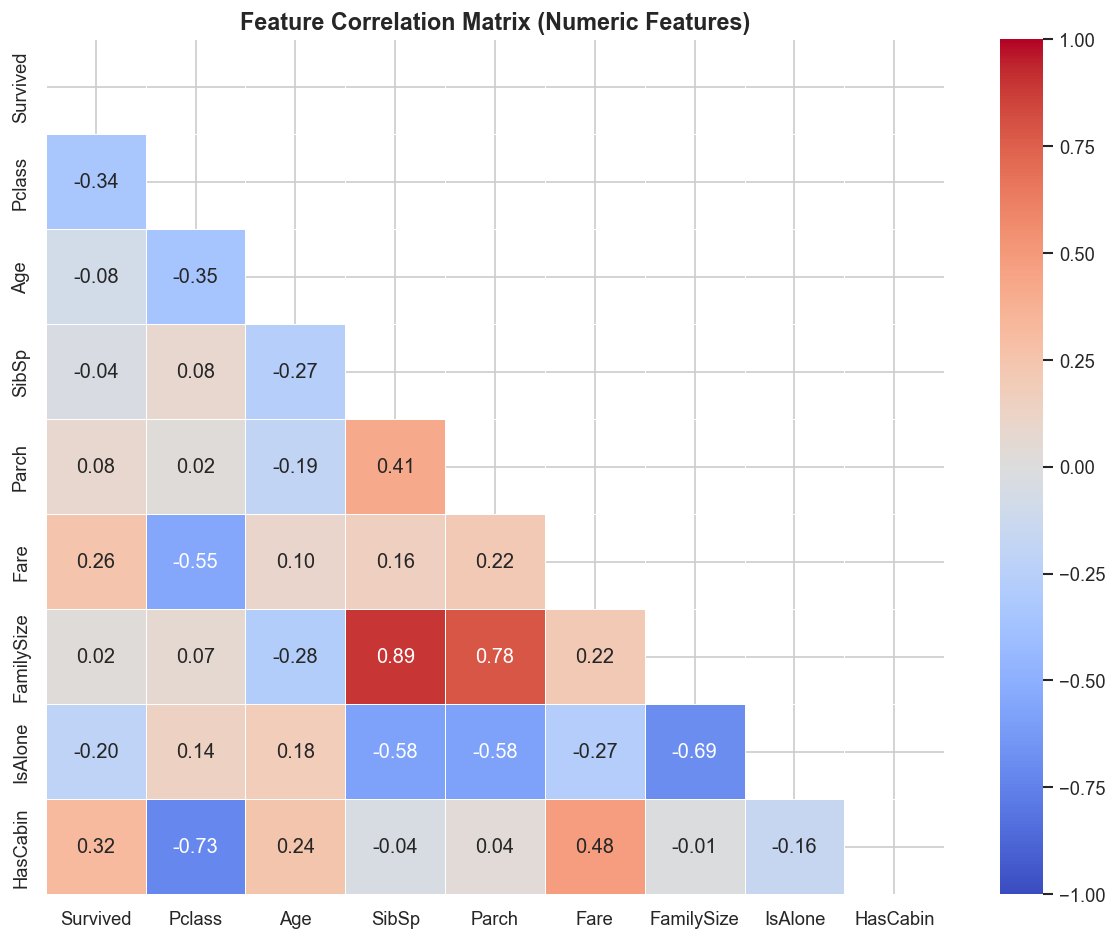

In [12]:
num_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize", "IsAlone", "HasCabin"]
corr = df_clean[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title("Feature Correlation Matrix (Numeric Features)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()